# Домашняя работа 10-11

In [40]:
import os
import math
import time
import random
import pandas as pd
import json
from dataclasses import dataclass
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.models import resnet18,ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 64
EPOCHS = 4 if FAST_MODE else 12
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

Device: cuda


## Часть A

In [3]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

IMG_SIZE = 32

def load_cifar100(data_dir: str = DATA_DIR, USE_AUG: bool = False):
    if USE_AUG:
        tf_train = transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])

        tf_test = transforms.Compose([
            transforms.Resize(IMG_SIZE + 32),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        ])
    else:
        tf_train = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        ])

    ds_train_full = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True,transform=tf_train)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full_base, ds_test_base = load_cifar100(USE_AUG=False)
class_names = ds_train_full_base.classes
print("Train full:", len(ds_train_full_base))
print("Test:", len(ds_test_base))
print("Classes:", class_names)

ds_train_full_aug, ds_test_aug = load_cifar100(USE_AUG=True)
class_names = ds_train_full_aug.classes
print("Train full:", len(ds_train_full_aug))
print("Test:", len(ds_test_aug))
print("Classes:", class_names)


Train full: 50000
Test: 10000
Classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtl

In [4]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader_base, val_loader_base, test_loader_base = make_loaders(ds_train_full_base, ds_test_base)

batch_base = next(iter(train_loader_base))
x_base, y_base = batch_base
print("x:", x_base.shape, x_base.dtype)
print("y:", y_base.shape, y_base.dtype)

train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(ds_train_full_aug, ds_test_aug)

batch_aug = next(iter(train_loader_aug))
x_aug, y_aug = batch_aug
print("x:", x_aug.shape, x_aug.dtype)
print("y:", y_aug.shape, y_aug.dtype)

x: torch.Size([64, 3, 32, 32]) torch.float32
y: torch.Size([64]) torch.int64
x: torch.Size([64, 3, 32, 32]) torch.float32
y: torch.Size([64]) torch.int64


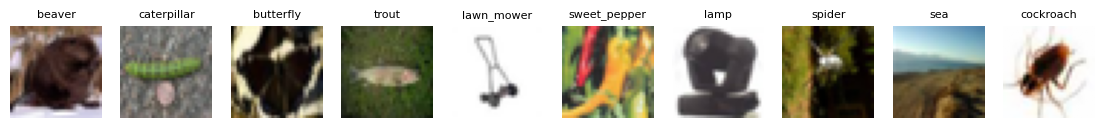

In [5]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader_base, n=10)

In [6]:
INPUT_DIM = 32 * 32 * 3
NUM_CLASSES = 100

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Trainable params: 643492


In [7]:
with torch.no_grad():
    x0 = torch.randn(2, 3, 32, 32).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 32, 32]) Output logits: torch.Size([2, 100])


In [43]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "", save: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save:
        plt.savefig(save,dpi=300,bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, train_loader: DataLoader, val_loader: DataLoader, model: nn.Module, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Experiment C1|simple-cnn-base | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 643492
Epoch 01/12 | lr 1.00e-03 | train loss 3.6753, acc 0.137 | val loss 3.1670, acc 0.233 | 16.9s
Epoch 02/12 | lr 1.00e-03 | train loss 2.8750, acc 0.282 | val loss 2.7907, acc 0.295 | 16.2s
Epoch 03/12 | lr 1.00e-03 | train loss 2.4565, acc 0.365 | val loss 2.5452, acc 0.356 | 16.2s
Epoch 04/12 | lr 1.00e-03 | train loss 2.1618, acc 0.432 | val loss 2.4203, acc 0.386 | 16.3s
Epoch 05/12 | lr 1.00e-03 | train loss 1.9189, acc 0.484 | val loss 2.4341, acc 0.386 | 15.8s
Epoch 06/12 | lr 1.00e-03 | train loss 1.6989, acc 0.534 | val loss 2.4159, acc 0.399 | 16.1s
Epoch 07/12 | lr 1.00e-03 | train loss 1.5135, acc 0.578 | val loss 2.5039, acc 0.400 | 15.7s
Epoch 08/12 | lr 1.00e-03 | train loss 1.3322, acc 0.622 | val loss 2.6341, acc 0.400 | 15.6s
Epoch 09/12 | lr 1.00e-03 | train loss 1.1648, acc 0.664 | val loss 2.7666, acc 0.400 | 15.2s
Epoch 10/12 | lr 1.00e-03 | train loss 1.0041, acc 0.708 | v

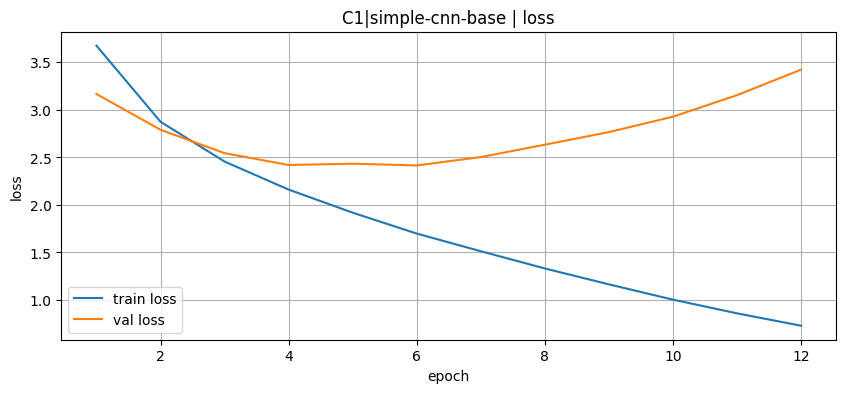

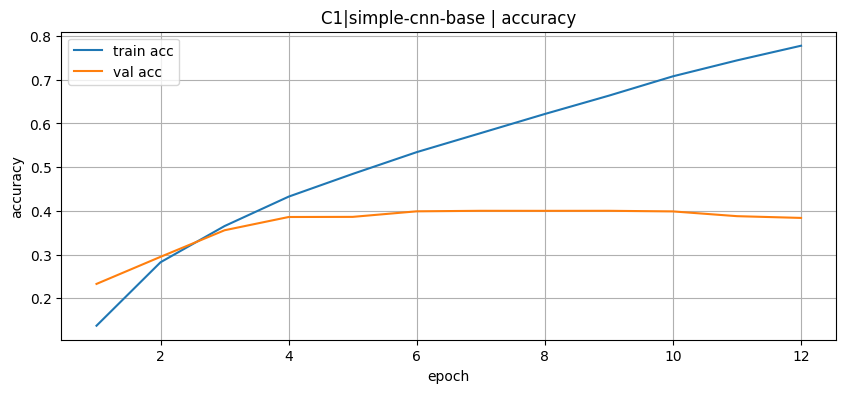

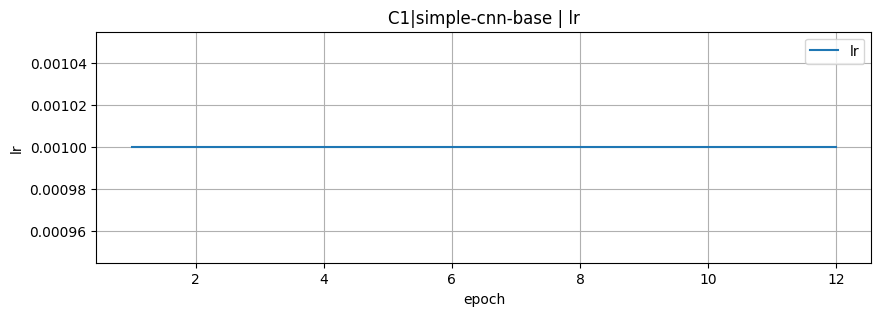


Experiment C2|simple-cnn-aug | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 643492
Epoch 01/12 | lr 1.00e-03 | train loss 3.7707, acc 0.122 | val loss 3.3566, acc 0.194 | 19.0s
Epoch 02/12 | lr 1.00e-03 | train loss 3.1315, acc 0.231 | val loss 2.9422, acc 0.274 | 19.3s
Epoch 03/12 | lr 1.00e-03 | train loss 2.8236, acc 0.291 | val loss 2.7778, acc 0.304 | 19.4s
Epoch 04/12 | lr 1.00e-03 | train loss 2.6223, acc 0.333 | val loss 2.6758, acc 0.323 | 19.1s
Epoch 05/12 | lr 1.00e-03 | train loss 2.4823, acc 0.362 | val loss 2.5915, acc 0.346 | 19.1s
Epoch 06/12 | lr 1.00e-03 | train loss 2.3550, acc 0.389 | val loss 2.5057, acc 0.366 | 19.1s
Epoch 07/12 | lr 1.00e-03 | train loss 2.2568, acc 0.410 | val loss 2.4916, acc 0.369 | 19.0s
Epoch 08/12 | lr 1.00e-03 | train loss 2.1662, acc 0.429 | val loss 2.4141, acc 0.392 | 19.4s
Epoch 09/12 | lr 1.00e-03 | train loss 2.0982, acc 0.447 | val loss 2.4264, acc 0.386 | 19.5s
Epoch 10/12 | lr 1.00e-03 | train loss 2.0318, acc 0.459 | va

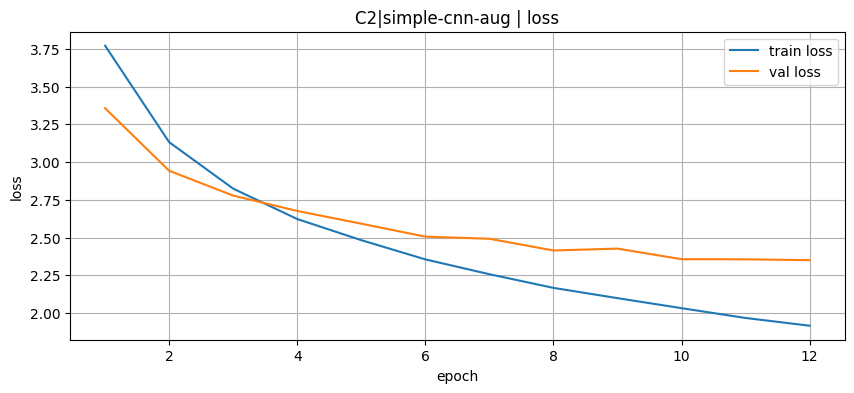

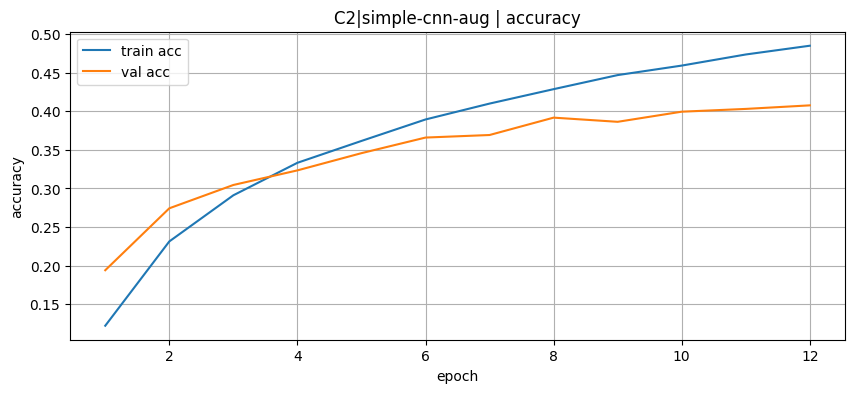

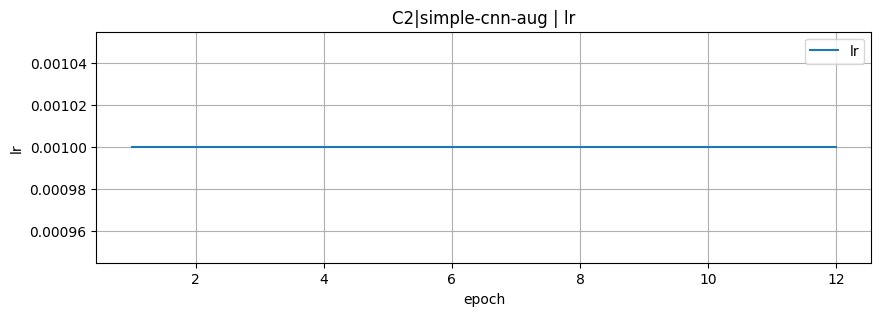

In [10]:
res_cnn_c1 = run_experiment("C1|simple-cnn-base", train_loader_base, val_loader_base, SimpleCNN(NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_c1["history"], title="C1|simple-cnn-base")

res_cnn_c2 = run_experiment("C2|simple-cnn-aug", train_loader_aug, val_loader_aug, SimpleCNN(NUM_CLASSES), lr=1e-3, epochs=EPOCHS)
plot_history(res_cnn_c2["history"], title="C2|simple-cnn-aug")

In [11]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [12]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 100, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=100, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Trainable params (resnet18-head-only): 51300

C3|resnet18-head-only
Epoch 01/8 | lr 1.00e-03 | train loss 3.6995, acc 0.166 | val loss 3.3587, acc 0.223 | 19.6s
Epoch 02/8 | lr 1.00e-03 | train loss 3.3104, acc 0.225 | val loss 3.2568, acc 0.241 | 19.4s
Epoch 03/8 | lr 1.00e-03 | train loss 3.2232, acc 0.236 | val loss 3.2555, acc 0.253 | 19.7s
Epoch 04/8 | lr 1.00e-03 | train loss 3.1808, acc 0.242 | val loss 3.2130, acc 0.249 | 18.9s
Epoch 05/8 | lr 1.00e-03 | train loss 3.1539, acc 0.252 | val loss 3.2138, acc 0.253 | 19.5s
Epoch 06/8 | lr 1.00e-03 | train loss 3.1404, acc 0.253 | val loss 3.1993, acc 0.252 | 19.1s
Epoch 07/8 | lr 1.00e-03 | train loss 3.1173, acc 0.255 | val loss 3.2334, acc 0.258 | 19.1s
Epoch 08/8 | lr 1.00e-03 | train loss 3.1158, acc 0.255 | val loss 3.1983, acc 0.260 | 19.5s


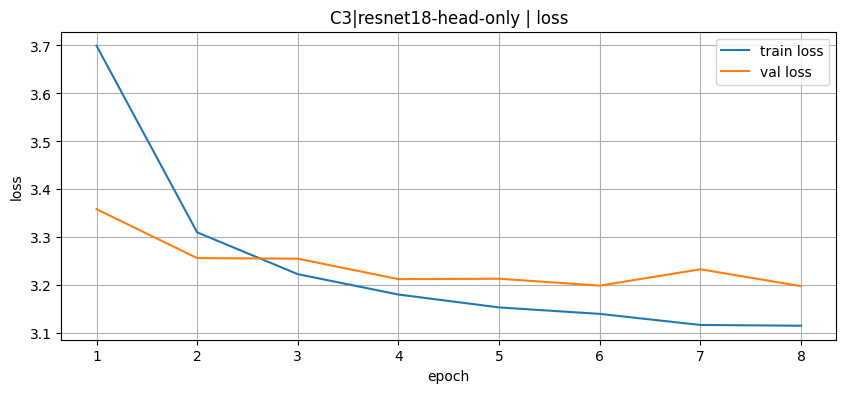

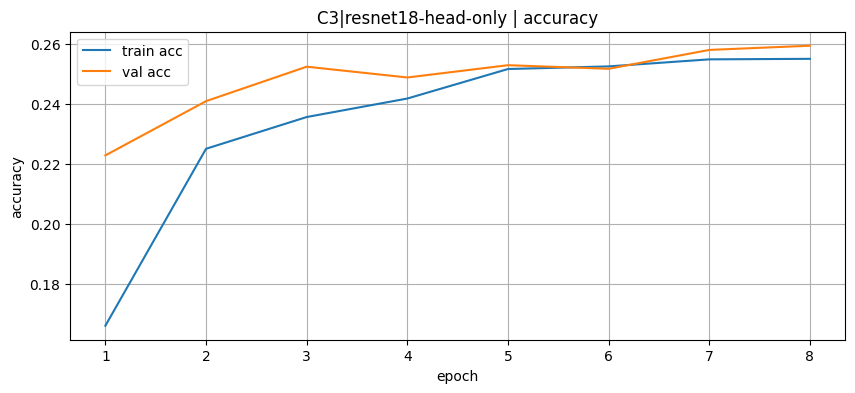

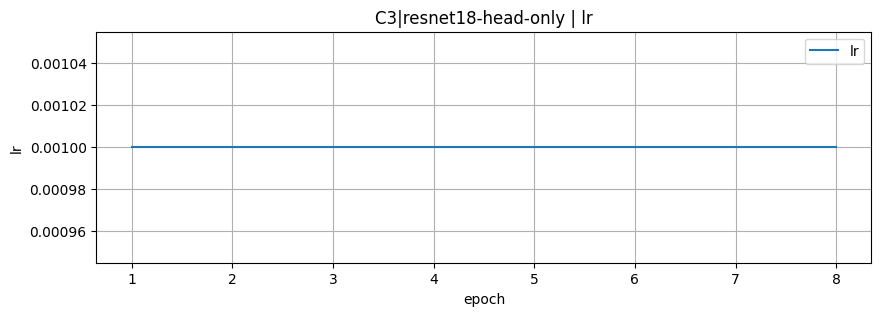

In [13]:
model_head = build_resnet18(num_classes=100, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (resnet18-head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("C3|resnet18-head-only")
resnet_c3 = fit(model_head, train_loader_aug, val_loader_aug, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(resnet_c3, title="C3|resnet18-head-only")

Trainable params (resnet18-finetune): 8445028

C4|resnet18-finetune
Epoch 01/8 | lr 1.00e-04 | train loss 2.9240, acc 0.283 | val loss 2.7537, acc 0.316 | 26.1s
Epoch 02/8 | lr 1.00e-04 | train loss 2.5782, acc 0.340 | val loss 2.5936, acc 0.344 | 25.3s
Epoch 03/8 | lr 1.00e-04 | train loss 2.3952, acc 0.379 | val loss 2.4630, acc 0.377 | 25.9s
Epoch 04/8 | lr 1.00e-04 | train loss 2.2520, acc 0.409 | val loss 2.3902, acc 0.391 | 26.2s
Epoch 05/8 | lr 1.00e-04 | train loss 2.1347, acc 0.432 | val loss 2.3599, acc 0.401 | 26.1s
Epoch 06/8 | lr 1.00e-04 | train loss 2.0387, acc 0.452 | val loss 2.3087, acc 0.409 | 26.8s
Epoch 07/8 | lr 1.00e-04 | train loss 1.9686, acc 0.468 | val loss 2.3175, acc 0.412 | 27.5s
Epoch 08/8 | lr 1.00e-04 | train loss 1.8897, acc 0.483 | val loss 2.3219, acc 0.412 | 26.5s


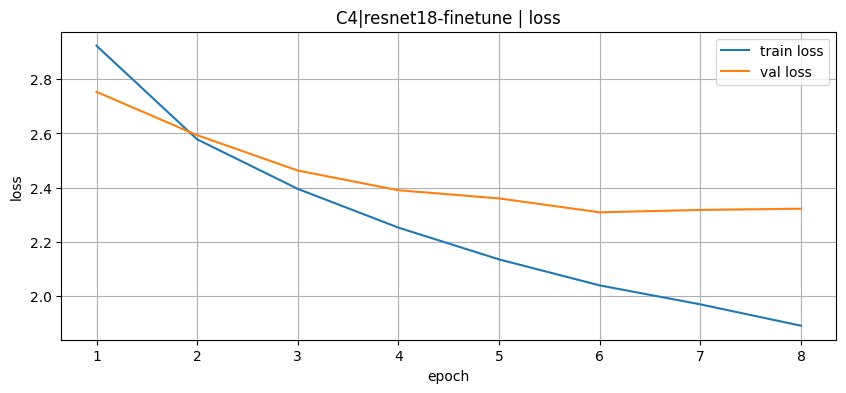

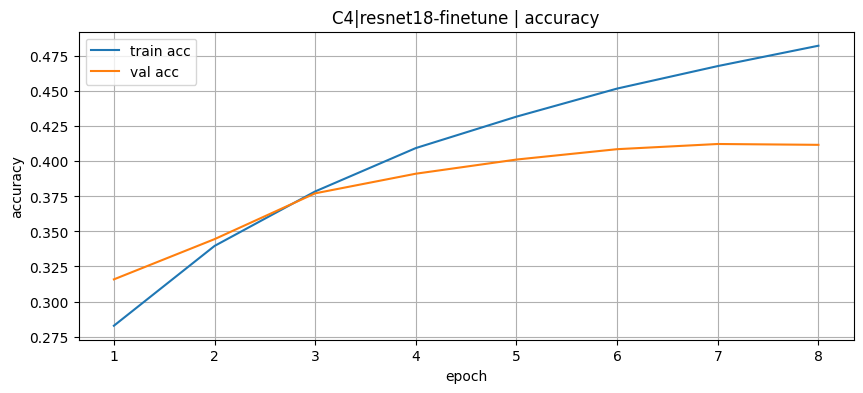

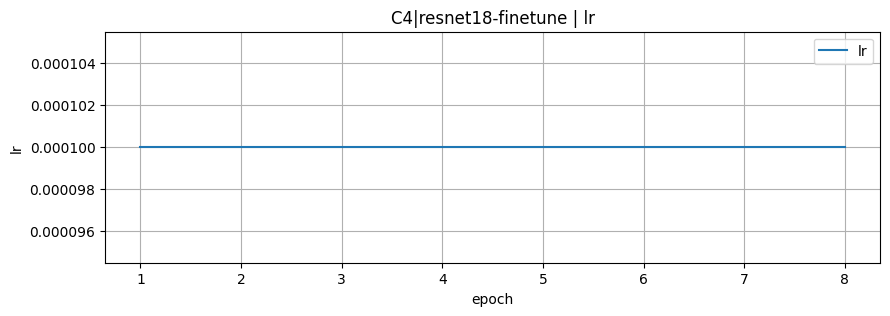

In [14]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (resnet18-finetune):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("C4|resnet18-finetune")
resnet_c4 = fit(model_head, train_loader_aug, val_loader_aug, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(resnet_c4, title="C4|resnet18-finetune")

Лучшей моделью вышла C4|resnet18-finetune с best_val_accuracy = 0.417

Оценка на test:

In [15]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_resnet_c4 = accuracy_on_loader(model_head, test_loader_aug)
print("Test acc (ResNet C4):", round(test_acc_resnet_c4, 4))

Test acc (ResNet C4): 0.2403


## Часть B

In [31]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.3          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_resnet50_fpn_v2"
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=4, score_thr=0.3, iou_thr=0.5, model_name='fasterrcnn_resnet50_fpn_v2')

In [32]:
from xml.etree import ElementTree as ET
from PIL import Image

class VocDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, root: str, year="2012", image_set="train"):
        from torchvision.datasets import VOCDetection
        # скачиваем через torchvision
        VOCDetection(root=root, year=year, image_set=image_set, download=True)
        self.voc_root = os.path.join(root, f"VOCdevkit/VOC{year}")
        self.img_dir = os.path.join(self.voc_root, "JPEGImages")
        self.ann_dir = os.path.join(self.voc_root, "Annotations")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.endswith(".jpg")])
        if len(self.imgs) == 0:
            raise RuntimeError("Нет изображений в VOC.")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        ann_path = os.path.join(self.ann_dir, self.imgs[idx].replace(".jpg", ".xml"))

        img = Image.open(img_path).convert("RGB")

        tree = ET.parse(ann_path)
        root = tree.getroot()

        boxes = []
        labels = []
        for obj in root.findall("object"):
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(1)  # для simplicity все объекты = 1

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        from torchvision.transforms import ToTensor
        img_t = ToTensor()(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = VocDetectionDataset(root=cfg.data_dir, year="2012")
len(dataset), dataset[0][0].shape, dataset[0][1].keys()

(17125,
 torch.Size([3, 500, 486]),
 dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd']))

In [33]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_resnet50_fpn_v2
person_label: 1


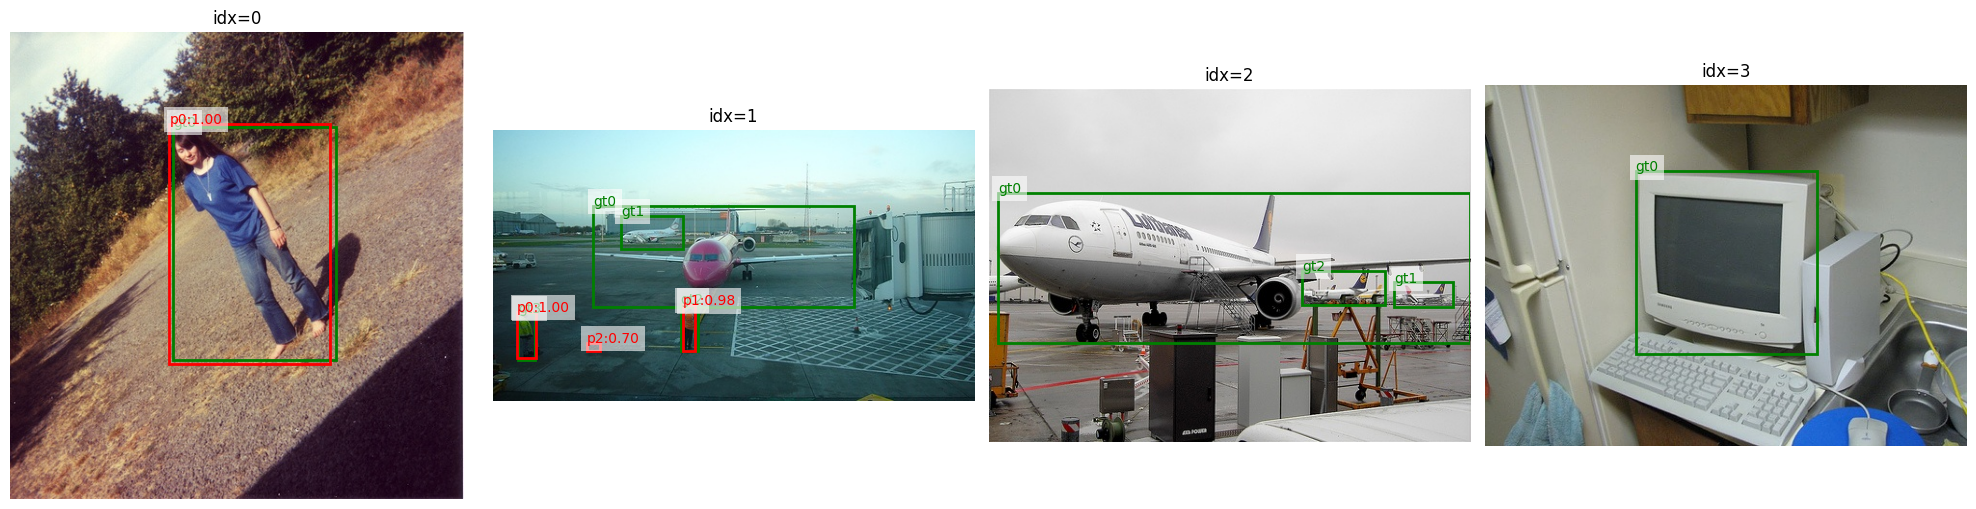

In [51]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.savefig("artifacts/figures/detection_examples.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": round(precision,4),
        "recall@IoU": round(recall,4),
        "F1@IoU": round(f1,4),
        "mean_IoU_matched": round(mean_iou,4),
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(100, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics_v1 = evaluate_subset(eval_indices)
metrics_v1

{'TP': 89.0,
 'FP': 129.0,
 'FN': 184.0,
 'precision@IoU': 0.4083,
 'recall@IoU': 0.326,
 'F1@IoU': 0.3625,
 'mean_IoU_matched': 0.854}

In [36]:
cfg.score_thr = 0.7

if cfg.fast_mode:
    eval_indices = list(range(min(100, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics_v2 = evaluate_subset(eval_indices)
metrics_v2

{'TP': 86.0,
 'FP': 55.0,
 'FN': 187.0,
 'precision@IoU': 0.6099,
 'recall@IoU': 0.315,
 'F1@IoU': 0.4155,
 'mean_IoU_matched': 0.8597}

## Сохранение артефактов

In [ ]:
runs = pd.DataFrame(columns=["experiment_id","task","dataset",
                             "seed","model_summary",
                             "optimizer","lr","epochs_trained",
                             "best_val_accuracy","test_accuracy",
                             "precision","recall","mean_iou","notes"])
runs.loc[len(runs)] = ["C1","classification","CIFAR100",RANDOM_STATE,"Conv2D(3→32,3x3)+Pool2D | Conv2D(32→64,3x3)+Pool2D | Conv2D(64→128,3x3)+Pool2D | Flatten | Linear(2048→256) | Linear(256→num_classes)","Adam",1e-3,EPOCHS,res_cnn_c1["history"]["val_acc"][-1],float("nan"),float("nan"),float("nan"),float("nan"),"simple CNN, no aug"]
runs.loc[len(runs)] = ["C2","classification","CIFAR100",RANDOM_STATE,"Conv2D(3→32,3x3)+Pool2D | Conv2D(32→64,3x3)+Pool2D | Conv2D(64→128,3x3)+Pool2D | Flatten | Linear(2048→256) | Linear(256→num_classes)","Adam",1e-3,EPOCHS,res_cnn_c2["history"]["val_acc"][-1],float("nan"),float("nan"),float("nan"),float("nan"),"simple CNN, with aug"]
runs.loc[len(runs)] = ["C3","classification","CIFAR100",RANDOM_STATE,"ResNet18 with Weights IMAGENET1K_V1","Adam",1e-3,EPOCHS,resnet_c3["val_acc"][-1],float("nan"),float("nan"),float("nan"),float("nan"),"resnet18 head only"]
runs.loc[len(runs)] = ["C4","classification","CIFAR100",RANDOM_STATE,"ResNet18 with Weights IMAGENET1K_V1","Adam",1e-3,EPOCHS,resnet_c4["val_acc"][-1],round(test_acc_resnet_c4, 4),float("nan"),float("nan"),float("nan"),"resnet18 fine-tune"]
runs.loc[len(runs)] = ["V1","detection","VOCDetection",RANDOM_STATE,"fasterrcnn_resnet50_fpn_v2","Adam",1e-3,EPOCHS_HEAD,float("nan"),float("nan"),metrics_v1["precision@IoU"],metrics_v1["recall@IoU"],metrics_v1["mean_IoU_matched"],"inference with score_threshold = 0.3"]
runs.loc[len(runs)] = ["V2","detection","VOCDetection",RANDOM_STATE,"fasterrcnn_resnet50_fpn_v2","Adam",1e-3,EPOCHS_FT,float("nan"),float("nan"),metrics_v2["precision@IoU"],metrics_v2["recall@IoU"],metrics_v2["mean_IoU_matched"],"inference with score_threshold = 0.7"]


runs.to_csv("artifacts/runs.csv", index=False)

In [39]:
torch.save(model_head.state_dict(), "artifacts/best_classifier.pt")

In [49]:
best_config = {
    "model": "C4 | ResNet18 with Weights IMAGENET1K_V1",
    "dataset": "CIFAR100",
    "transforms": "Resize,RandomResizedCrop,RandomHorizontalFlip,ToTensor,Normalize",
    "seed": RANDOM_STATE,
    "fast_mode": FAST_MODE,
    "epochs_trained": EPOCHS,
    "optimizer": "Adam",
    "lr": 1e-3,
    "best_val_accuracy":resnet_c4["val_acc"][-1],
    "test_accuracy":round(test_acc_resnet_c4, 4),
}

with open("artifacts/best_classifier_config.json","w") as f:
    json.dump(best_config,f,indent=4)

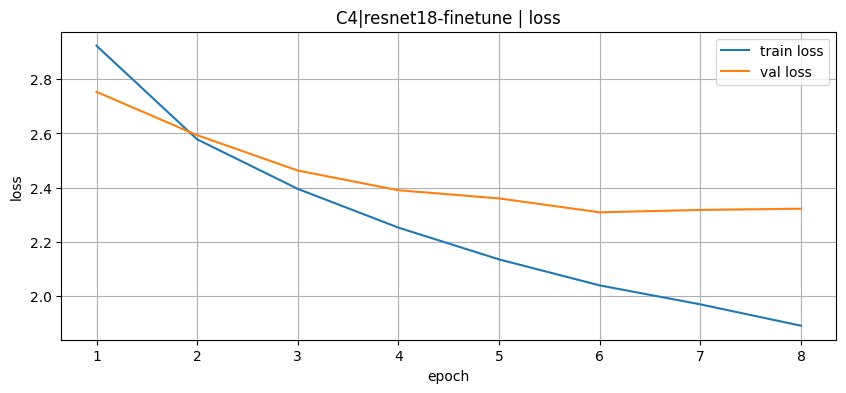

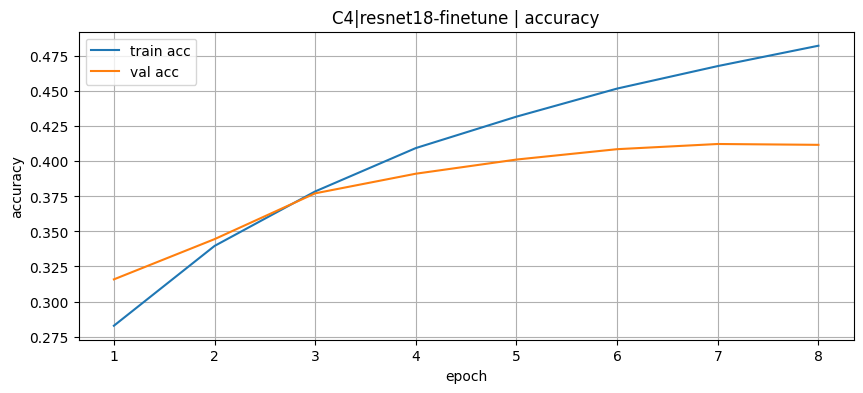

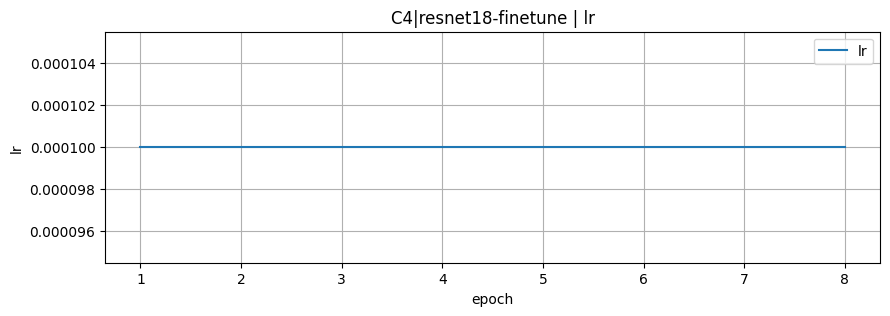

In [44]:
plot_history(resnet_c4, title="C4|resnet18-finetune",save="artifacts/figures/classification_curves_best.png")

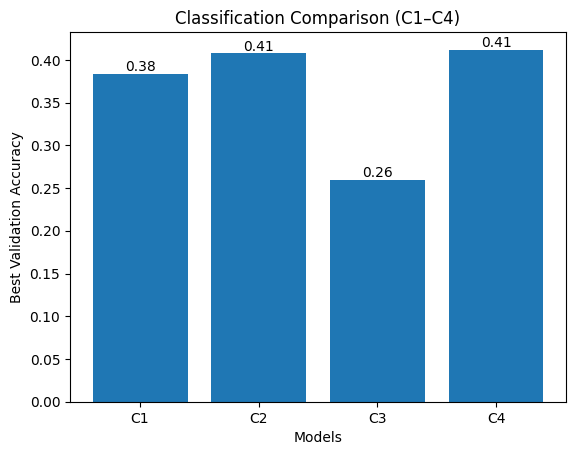

In [48]:
results = {
    "C1": res_cnn_c1["history"]["val_acc"][-1],
    "C2": res_cnn_c2["history"]["val_acc"][-1],
    "C3": resnet_c3["val_acc"][-1],
    "C4": resnet_c4["val_acc"][-1]
}

def classification_compare_plot(results: Dict[str, float]):
    models = list(results.keys())
    accuracies = list(results.values())

    plt.figure()
    plt.bar(models, accuracies)

    plt.title("Classification Comparison (C1–C4)")
    plt.xlabel("Models")
    plt.ylabel("Best Validation Accuracy")

    for i, v in enumerate(accuracies):
        plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

    plt.savefig("artifacts/figures/classification_compare.png",dpi=300,bbox_inches="tight")
    plt.show()

classification_compare_plot(results)

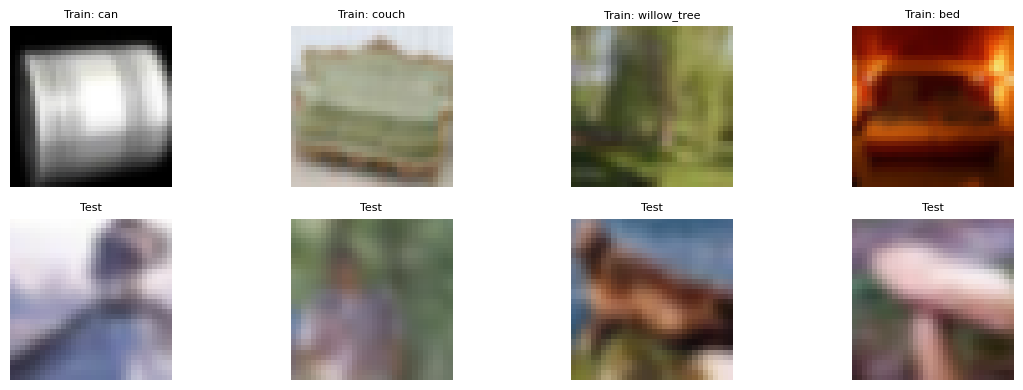

In [50]:
x_train, y_train = next(iter(train_loader_aug))
x_test, y_test = next(iter(test_loader_aug))

x_train = x_train[:n].cpu()
x_test = x_test[:n].cpu()
y_train = y_train[:n].cpu()

plt.figure(figsize=(12, 4))

# --- TRAIN (с аугментациями) ---
for i in range(n):
    img = denorm_cifar(x_train[i]).clamp(0, 1).permute(1, 2, 0).numpy()

    plt.subplot(2, n, i + 1)
    plt.imshow(img)
    plt.title(f"Train: {class_names[y_train[i].item()]}", fontsize=8)
    plt.axis("off")

# --- TEST (без рандома) ---
for i in range(n):
    img = denorm_cifar(x_test[i]).clamp(0, 1).permute(1, 2, 0).numpy()

    plt.subplot(2, n, n + i + 1)
    plt.imshow(img)
    plt.title("Test", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=300, bbox_inches="tight")
plt.show()


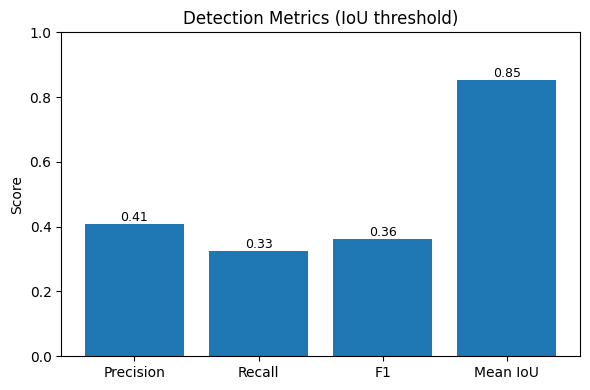

In [52]:
names = ["Precision", "Recall", "F1", "Mean IoU"]
values = [
    metrics_v1["precision@IoU"],
    metrics_v1["recall@IoU"],
    metrics_v1["F1@IoU"],
    metrics_v1["mean_IoU_matched"],
]

plt.figure(figsize=(6, 4))
plt.bar(names, values)

plt.title("Detection Metrics (IoU threshold)")
plt.ylabel("Score")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1) 
plt.tight_layout()

plt.savefig("artifacts/figures/detection_metrics.png", dpi=300, bbox_inches="tight")
plt.show()